In [ ]:
'LIFE EXPECTANCY DATA ANALYSIS AND MACHINE LEARNING MODEL'
# Clean data by encoding categorical features and performing feature engineering, visualize data with bar plots and scatter plots comparing averages and regions, form models that predict life expectancy by training and testing data on selected features to evaluate accuracy

In [ ]:
'DATA CLEANING AND EXPLORATORY DATA ANALYSIS'
# Drop redundant features, encode categorical features into numerical ones for feature engineering

In [1]:
from matplotlib.pyplot import figure
from scipy.ndimage import standard_deviation
!pip install scikit-learn

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import *

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier

life_df = pd.read_csv(r'C:\Users\mratk\AppData\Local\Life-Expectancy-Data-Updated.csv')


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
life_df.head()

,Country,Region,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,...,Diphtheria,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status_Developed,Economy_status_Developing,Life_expectancy
0,Turkiye,Middle East,2015,11.1,13.0,105.8240,1.32,97,65,27.8,...,97,0.08,11006,78.53,4.9,4.8,7.8,0,1,76.5
1,Spain,European Union,2015,2.7,3.3,57.9025,10.35,97,94,26.0,...,97,0.09,25742,46.44,0.6,0.5,9.7,1,0,82.8
2,India,Asia,2007,51.5,67.9,201.0765,1.57,60,35,21.2,...,64,0.13,1076,1183.21,27.1,28.0,5.0,0,1,65.4
3,Guyana,South America,2006,32.8,40.5,222.1965,5.68,93,74,25.3,...,93,0.79,4146,0.75,5.7,5.5,7.9,0,1,67.0
4,Israel,Middle East,2012,3.4,4.3,57.9510,2.89,97,89,27.0,...,94,0.08,33995,7.91,1.2,1.1,12.8,1,0,81.7


In [3]:
life_df['Region'].unique() # Return unique categorical variables for region

array(['Middle East', 'European Union', 'Asia', 'South America',
       'Central America and Caribbean', 'Rest of Europe', 'Africa',
       'Oceania', 'North America'], dtype=object)

In [4]:
region_map = {'Middle East': 1, 'European Union': 2, 'Asia': 3, 'South America': 4, 'Central America and Caribbean': 5, 'Rest of Europe': 6, 'Africa': 7, 'Oceania': 8, 'North America': 9} # Encode all categorical variables into numbers
life_df['Region Encoded'] = life_df['Region'].map(region_map) # Create column with numbers

In [5]:
life_df.head()

,Country,Region,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,...,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status_Developed,Economy_status_Developing,Life_expectancy,Region Encoded
0,Turkiye,Middle East,2015,11.1,13.0,105.8240,1.32,97,65,27.8,...,0.08,11006,78.53,4.9,4.8,7.8,0,1,76.5,1
1,Spain,European Union,2015,2.7,3.3,57.9025,10.35,97,94,26.0,...,0.09,25742,46.44,0.6,0.5,9.7,1,0,82.8,2
2,India,Asia,2007,51.5,67.9,201.0765,1.57,60,35,21.2,...,0.13,1076,1183.21,27.1,28.0,5.0,0,1,65.4,3
3,Guyana,South America,2006,32.8,40.5,222.1965,5.68,93,74,25.3,...,0.79,4146,0.75,5.7,5.5,7.9,0,1,67.0,4
4,Israel,Middle East,2012,3.4,4.3,57.9510,2.89,97,89,27.0,...,0.08,33995,7.91,1.2,1.1,12.8,1,0,81.7,1


In [6]:
life_df = life_df.drop(['Region'], axis=1) # Drop categorical variable after its encoding
life_df.head()

,Country,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,Polio,...,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status_Developed,Economy_status_Developing,Life_expectancy,Region Encoded
0,Turkiye,2015,11.1,13.0,105.8240,1.32,97,65,27.8,97,...,0.08,11006,78.53,4.9,4.8,7.8,0,1,76.5,1
1,Spain,2015,2.7,3.3,57.9025,10.35,97,94,26.0,97,...,0.09,25742,46.44,0.6,0.5,9.7,1,0,82.8,2
2,India,2007,51.5,67.9,201.0765,1.57,60,35,21.2,67,...,0.13,1076,1183.21,27.1,28.0,5.0,0,1,65.4,3
3,Guyana,2006,32.8,40.5,222.1965,5.68,93,74,25.3,92,...,0.79,4146,0.75,5.7,5.5,7.9,0,1,67.0,4
4,Israel,2012,3.4,4.3,57.9510,2.89,97,89,27.0,94,...,0.08,33995,7.91,1.2,1.1,12.8,1,0,81.7,1


In [7]:
mean = life_df.mean(numeric_only=True) # Determine mean for all numerical variables
print(mean)

Year                            2007.500000
Infant_deaths                     30.363792
Under_five_deaths                 42.938268
Adult_mortality                  192.251775
Alcohol_consumption                4.820882
Hepatitis_B                       84.292598
Measles                           77.344972
BMI                               25.032926
Polio                             86.499651
Diphtheria                        86.271648
Incidents_HIV                      0.894288
GDP_per_capita                 11540.924930
Population_mln                    36.675915
Thinness_ten_nineteen_years        4.865852
Thinness_five_nine_years           4.899825
Schooling                          7.632123
Economy_status_Developed           0.206704
Economy_status_Developing          0.793296
Life_expectancy                   68.856075
Region Encoded                     4.770950
dtype: float64


In [8]:
sd = life_df.std(numeric_only=True) # Determine standard deviation for numerical variables
print(sd)

Year                               4.610577
Infant_deaths                     27.538117
Under_five_deaths                 44.569974
Adult_mortality                  114.910281
Alcohol_consumption                3.981949
Hepatitis_B                       15.995511
Measles                           18.659693
BMI                                2.193905
Polio                             15.080365
Diphtheria                        15.534225
Incidents_HIV                      2.381389
GDP_per_capita                 16934.788931
Population_mln                   136.485867
Thinness_ten_nineteen_years        4.438234
Thinness_five_nine_years           4.525217
Schooling                          3.171556
Economy_status_Developed           0.405012
Economy_status_Developing          0.405012
Life_expectancy                    9.405608
Region Encoded                     2.296388
dtype: float64


In [9]:
life_df = life_df.drop(['Under_five_deaths'], axis=1) # Drop a redundant feature
life_df = life_df.drop(['Thinness_ten_nineteen_years'], axis=1) # Drop a redundant feature
life_df = life_df.drop(['Economy_status_Developing'], axis=1) # Drop a redundant feature
life_df.head()

,Country,Year,Infant_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,Polio,Diphtheria,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_five_nine_years,Schooling,Economy_status_Developed,Life_expectancy,Region Encoded
0,Turkiye,2015,11.1,105.8240,1.32,97,65,27.8,97,97,0.08,11006,78.53,4.8,7.8,0,76.5,1
1,Spain,2015,2.7,57.9025,10.35,97,94,26.0,97,97,0.09,25742,46.44,0.5,9.7,1,82.8,2
2,India,2007,51.5,201.0765,1.57,60,35,21.2,67,64,0.13,1076,1183.21,28.0,5.0,0,65.4,3
3,Guyana,2006,32.8,222.1965,5.68,93,74,25.3,92,93,0.79,4146,0.75,5.5,7.9,0,67.0,4
4,Israel,2012,3.4,57.9510,2.89,97,89,27.0,94,94,0.08,33995,7.91,1.1,12.8,1,81.7,1


In [ ]:
'DATA VISUALIZATION'
# Visualize relation between different features in scatter plots grouped by region and find averages of features by region to compare in bar plots

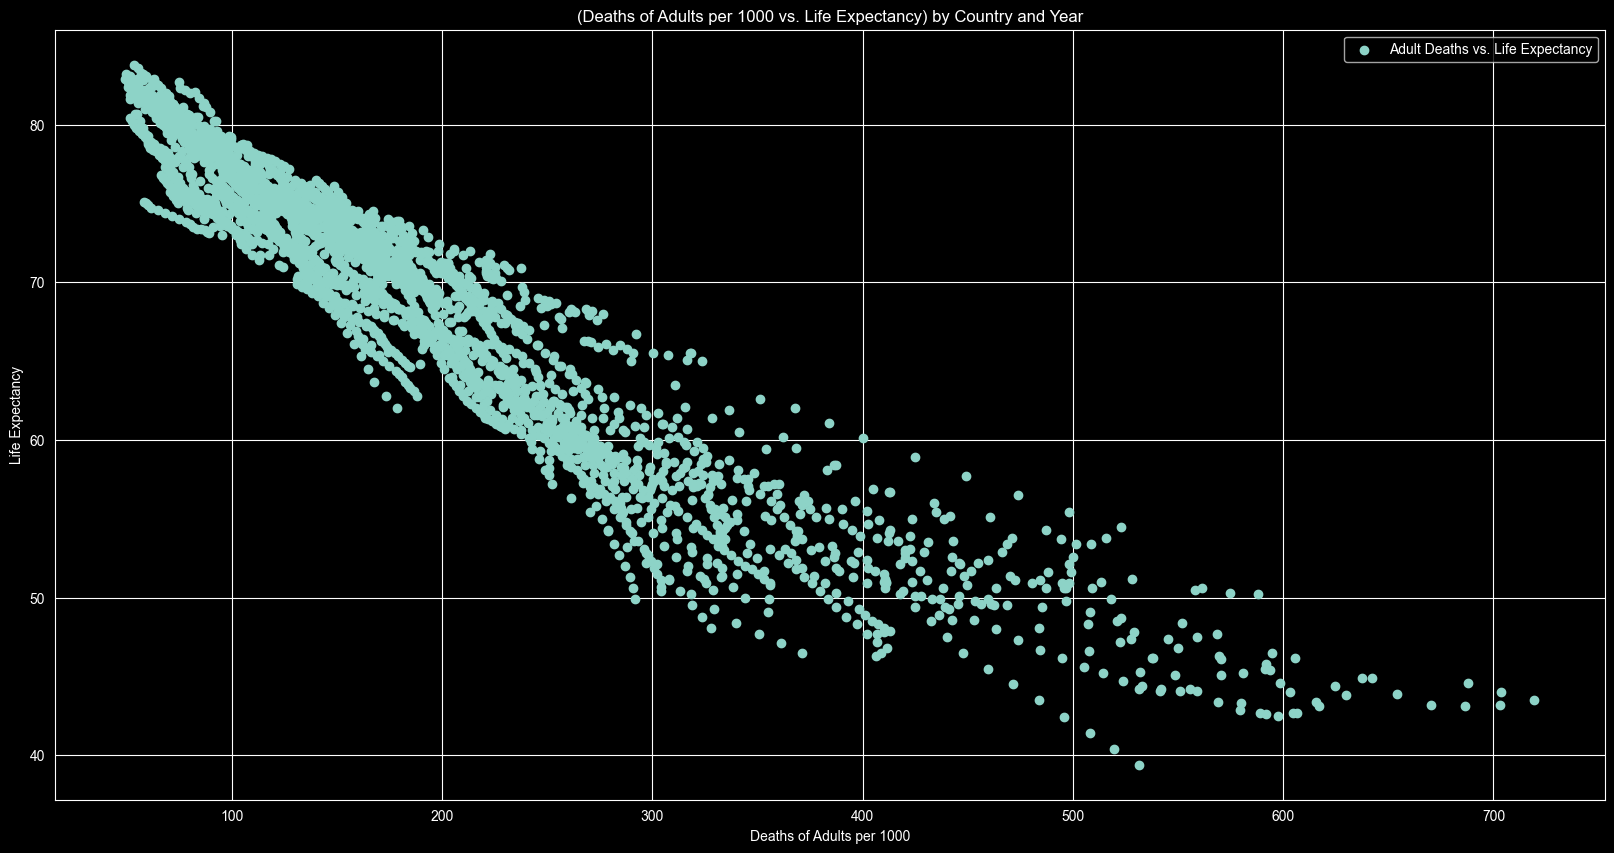

In [10]:
plt.figure(figsize=(20, 10))

plt.scatter(life_df['Adult_mortality'], life_df['Life_expectancy'], label='Adult Deaths vs. Life Expectancy')

plt.xlabel("Deaths of Adults per 1000")
plt.ylabel("Life Expectancy")
plt.title("(Deaths of Adults per 1000 vs. Life Expectancy) by Country and Year")
plt.legend()
plt.show()

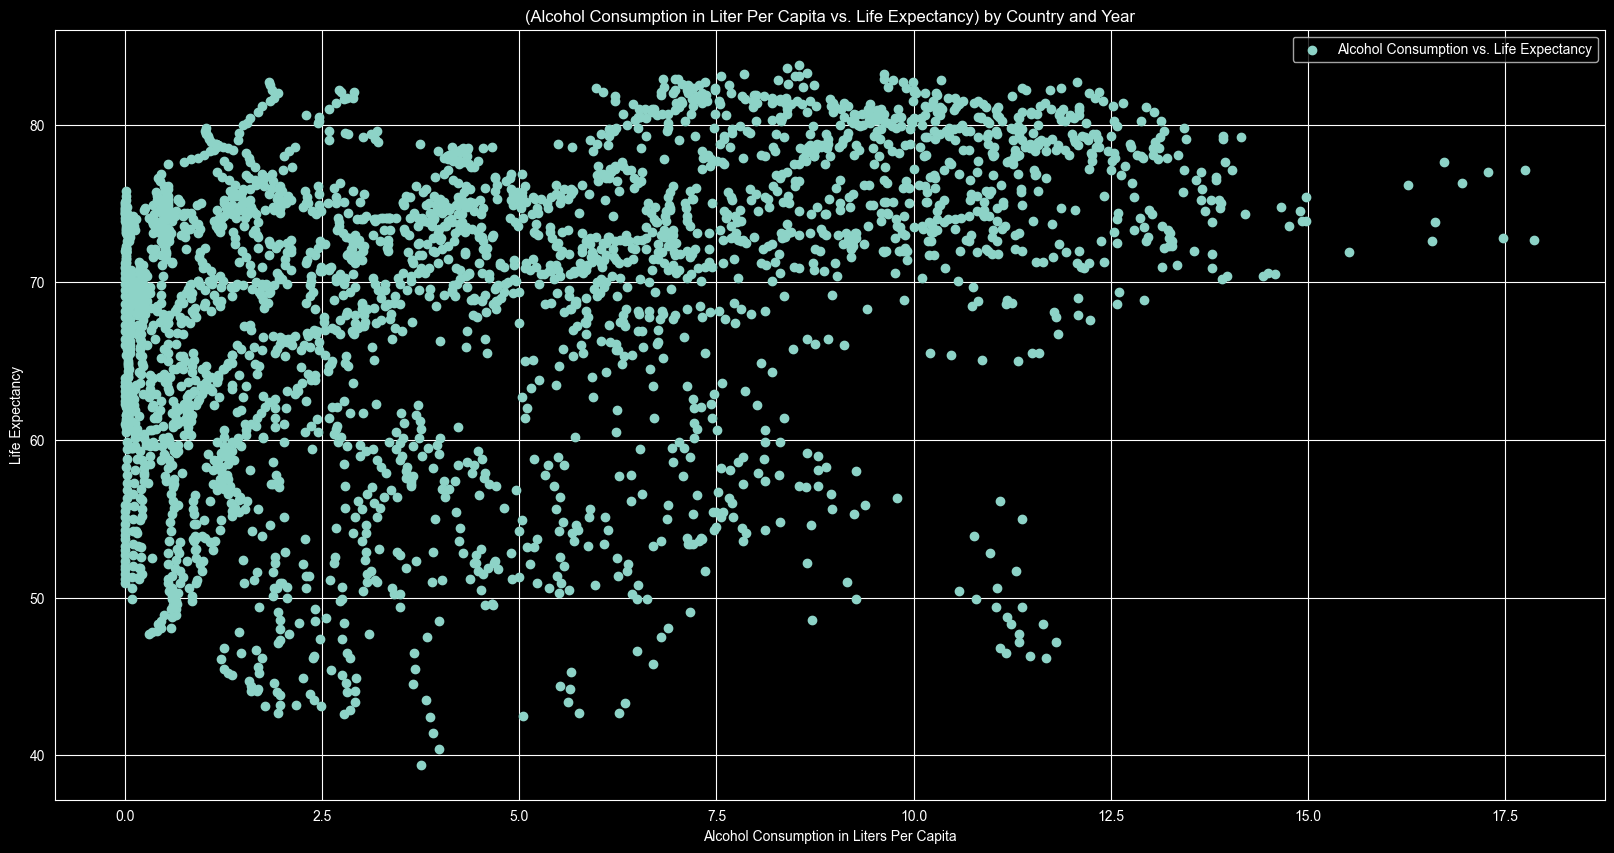

In [11]:
plt.figure(figsize=(20, 10))

plt.scatter(life_df['Alcohol_consumption'], life_df['Life_expectancy'], label='Alcohol Consumption vs. Life Expectancy')

plt.xlabel("Alcohol Consumption in Liters Per Capita")
plt.ylabel("Life Expectancy")
plt.title("(Alcohol Consumption in Liter Per Capita vs. Life Expectancy) by Country and Year")
plt.legend()
plt.show()

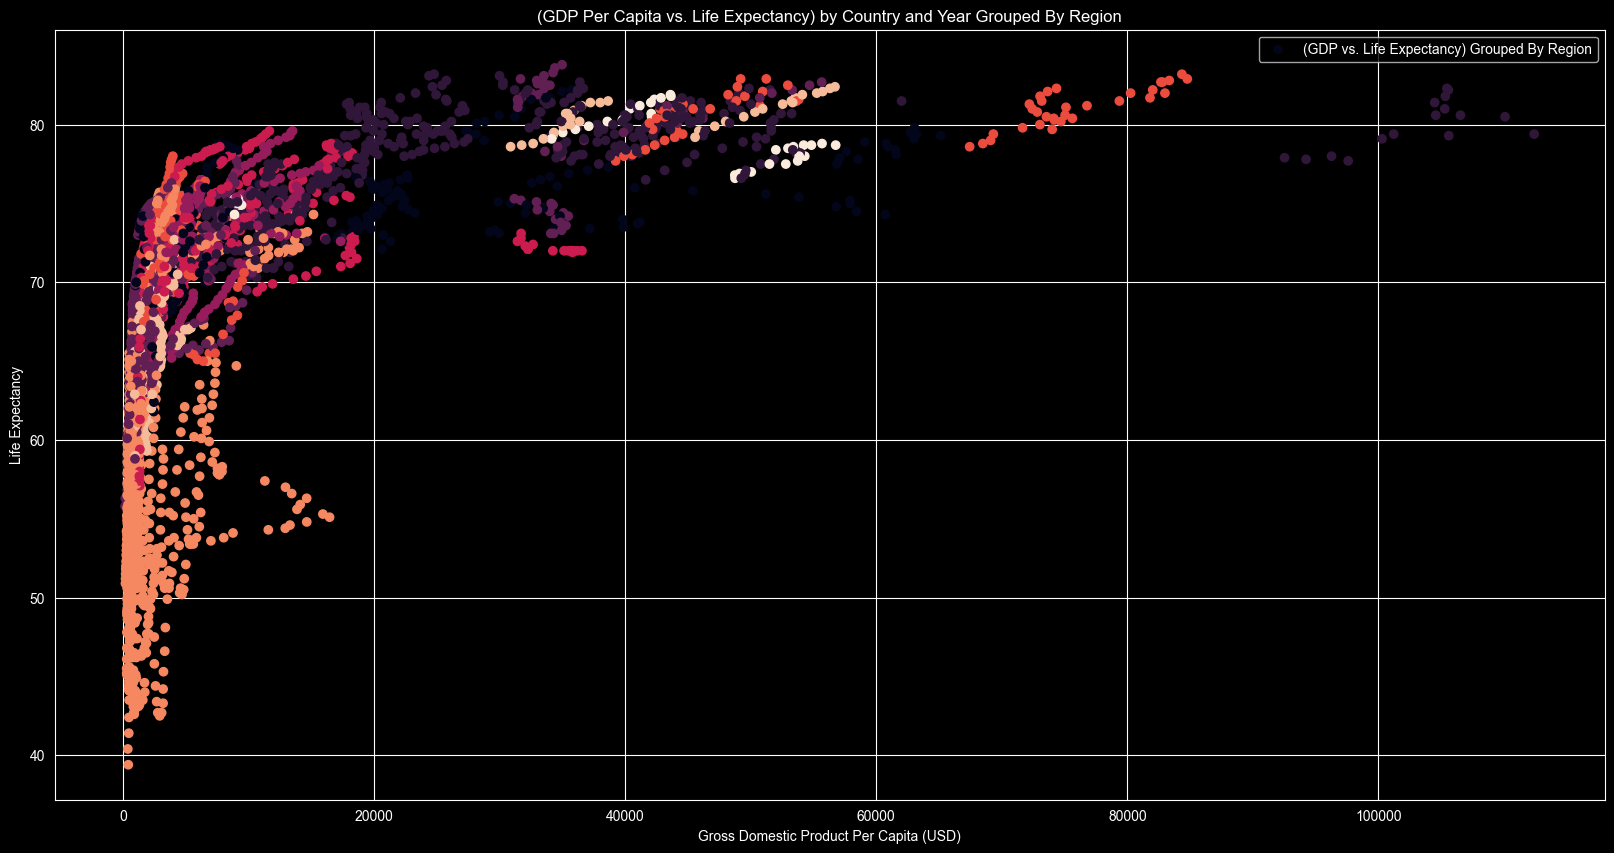

In [12]:
plt.figure(figsize=(20, 10))

plt.scatter(life_df['GDP_per_capita'], life_df['Life_expectancy'], c=life_df['Region Encoded'], label='(GDP vs. Life Expectancy) Grouped By Region')

plt.xlabel("Gross Domestic Product Per Capita (USD)")
plt.ylabel("Life Expectancy")
plt.title("(GDP Per Capita vs. Life Expectancy) by Country and Year Grouped By Region")
plt.legend()
plt.show()

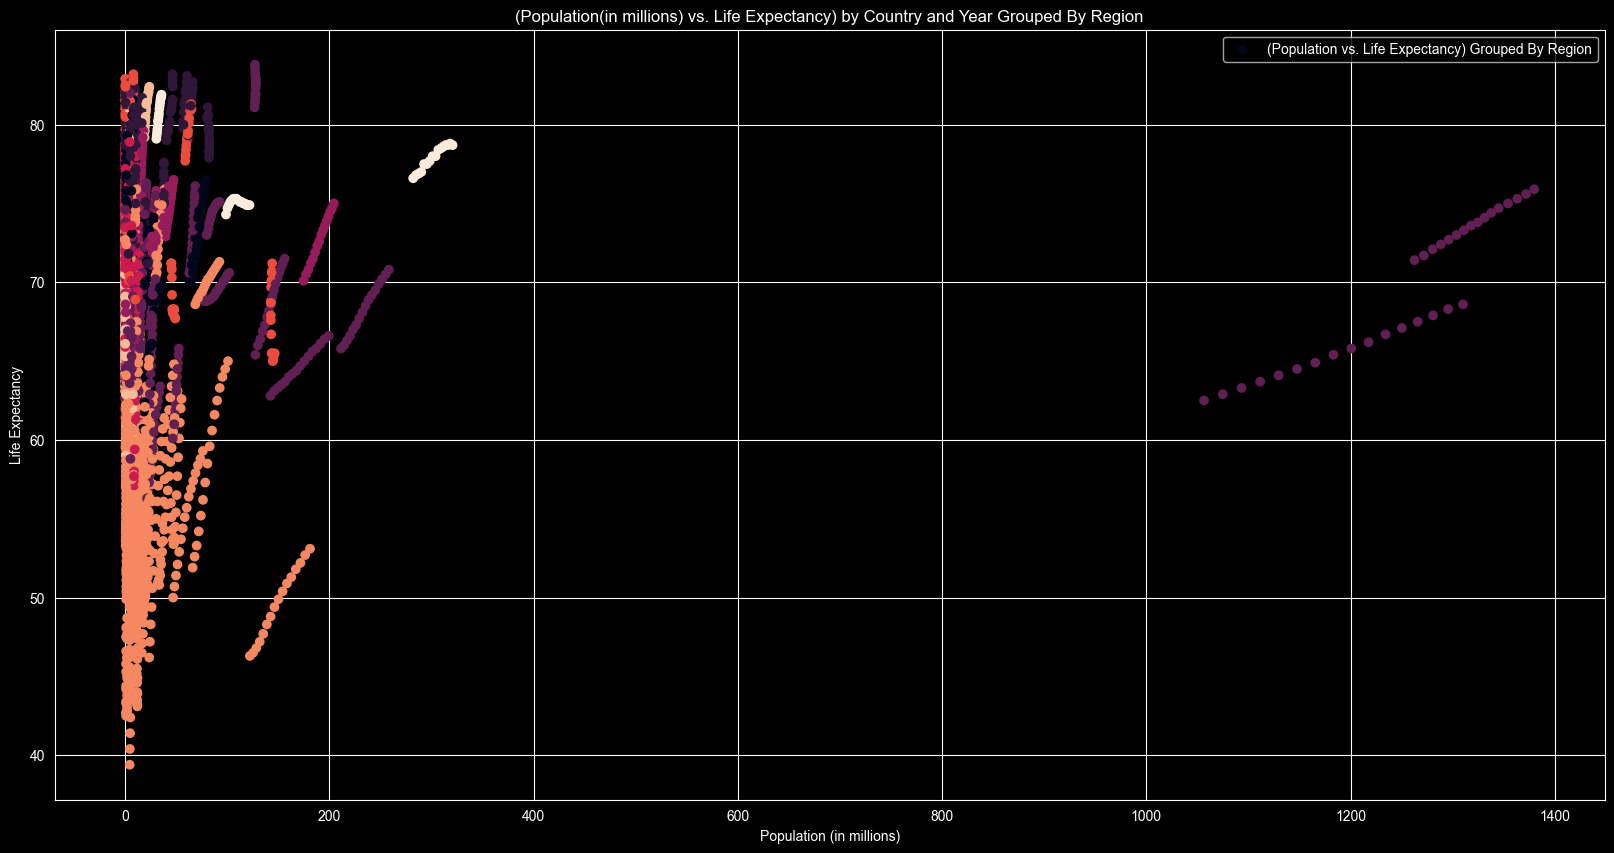

In [13]:
plt.figure(figsize=(20, 10))

plt.scatter(life_df['Population_mln'], life_df['Life_expectancy'], c=life_df['Region Encoded'], label='(Population vs. Life Expectancy) Grouped By Region')

plt.xlabel("Population (in millions)")
plt.ylabel("Life Expectancy")
plt.title("(Population(in millions) vs. Life Expectancy) by Country and Year Grouped By Region")
plt.legend()
plt.show()

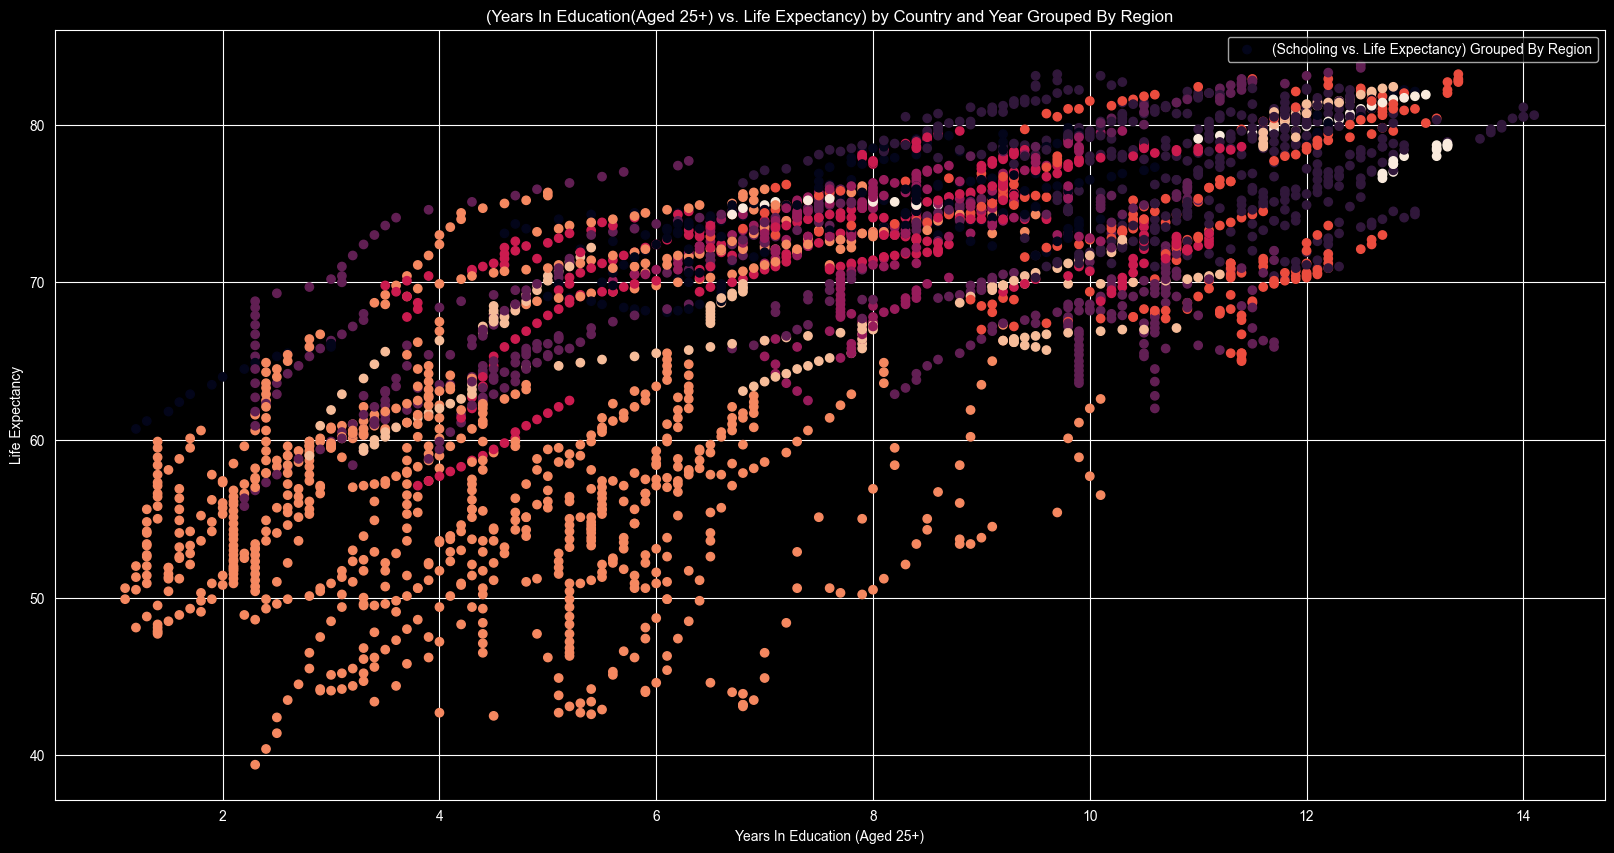

In [14]:
plt.figure(figsize=(20, 10))

plt.scatter(life_df['Schooling'], life_df['Life_expectancy'], c=life_df['Region Encoded'], label='(Schooling vs. Life Expectancy) Grouped By Region')

plt.xlabel("Years In Education (Aged 25+)")
plt.ylabel("Life Expectancy")
plt.title("(Years In Education(Aged 25+) vs. Life Expectancy) by Country and Year Grouped By Region")
plt.legend()
plt.show()

In [15]:
# Calculate average value of each feature variable in each region by grouping by encoded region number
HepatitisB_Region = life_df.groupby('Region Encoded')['Hepatitis_B'].mean()
Measles_Region = life_df.groupby('Region Encoded')['Measles'].mean()
Polio_Region = life_df.groupby('Region Encoded')['Polio'].mean()

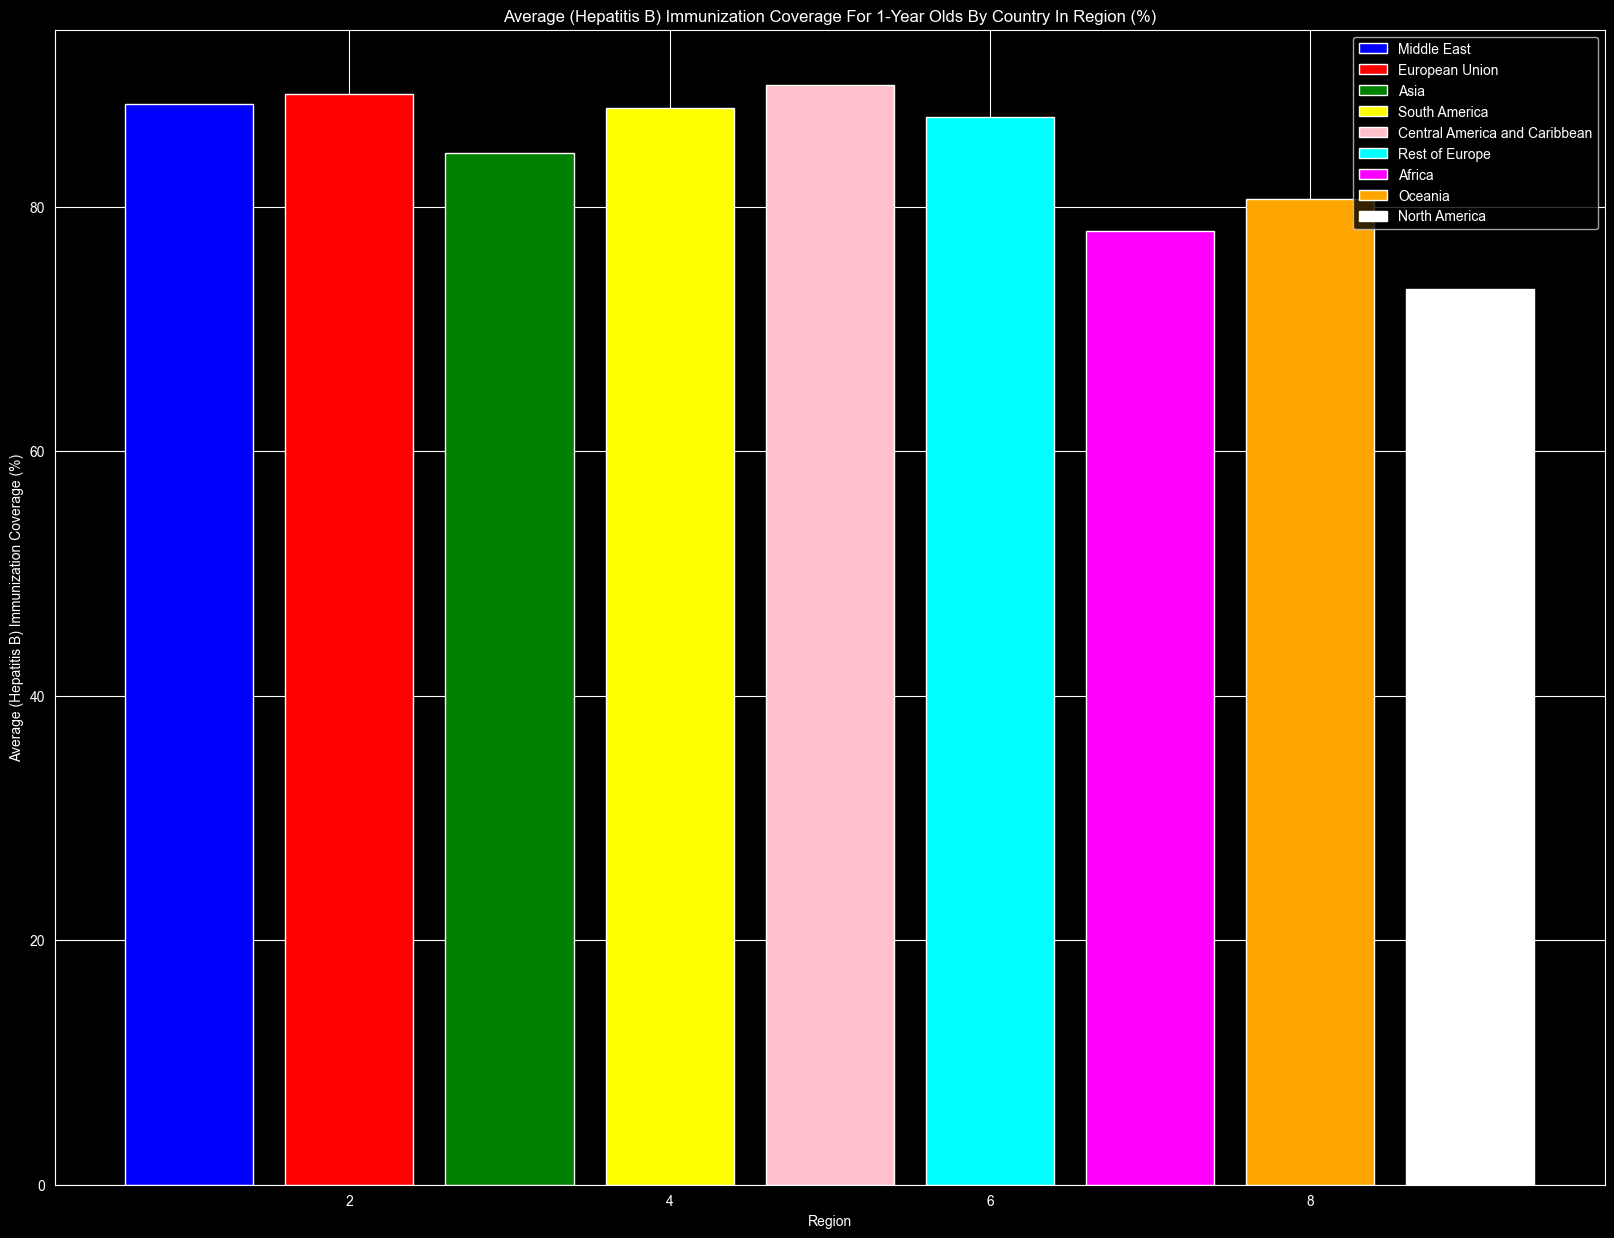

In [16]:
plt.figure(figsize=(20, 15))

# Display distribution by region of average value of (Hepatitis_B) vaccination and assign color, labels
plt.bar(HepatitisB_Region.index, HepatitisB_Region.values, color=['blue', 'red', 'green', 'yellow', 'pink', 'cyan', 'magenta', 'orange', 'white'], label=['Middle East', 'European Union', 'Asia', 'South America', 'Central America and Caribbean', 'Rest of Europe', 'Africa', 'Oceania', 'North America'])

plt.xlabel("Region")
plt.ylabel("Average (Hepatitis B) Immunization Coverage (%)")
plt.title("Average (Hepatitis B) Immunization Coverage For 1-Year Olds By Country In Region (%)")
plt.legend()
plt.show()

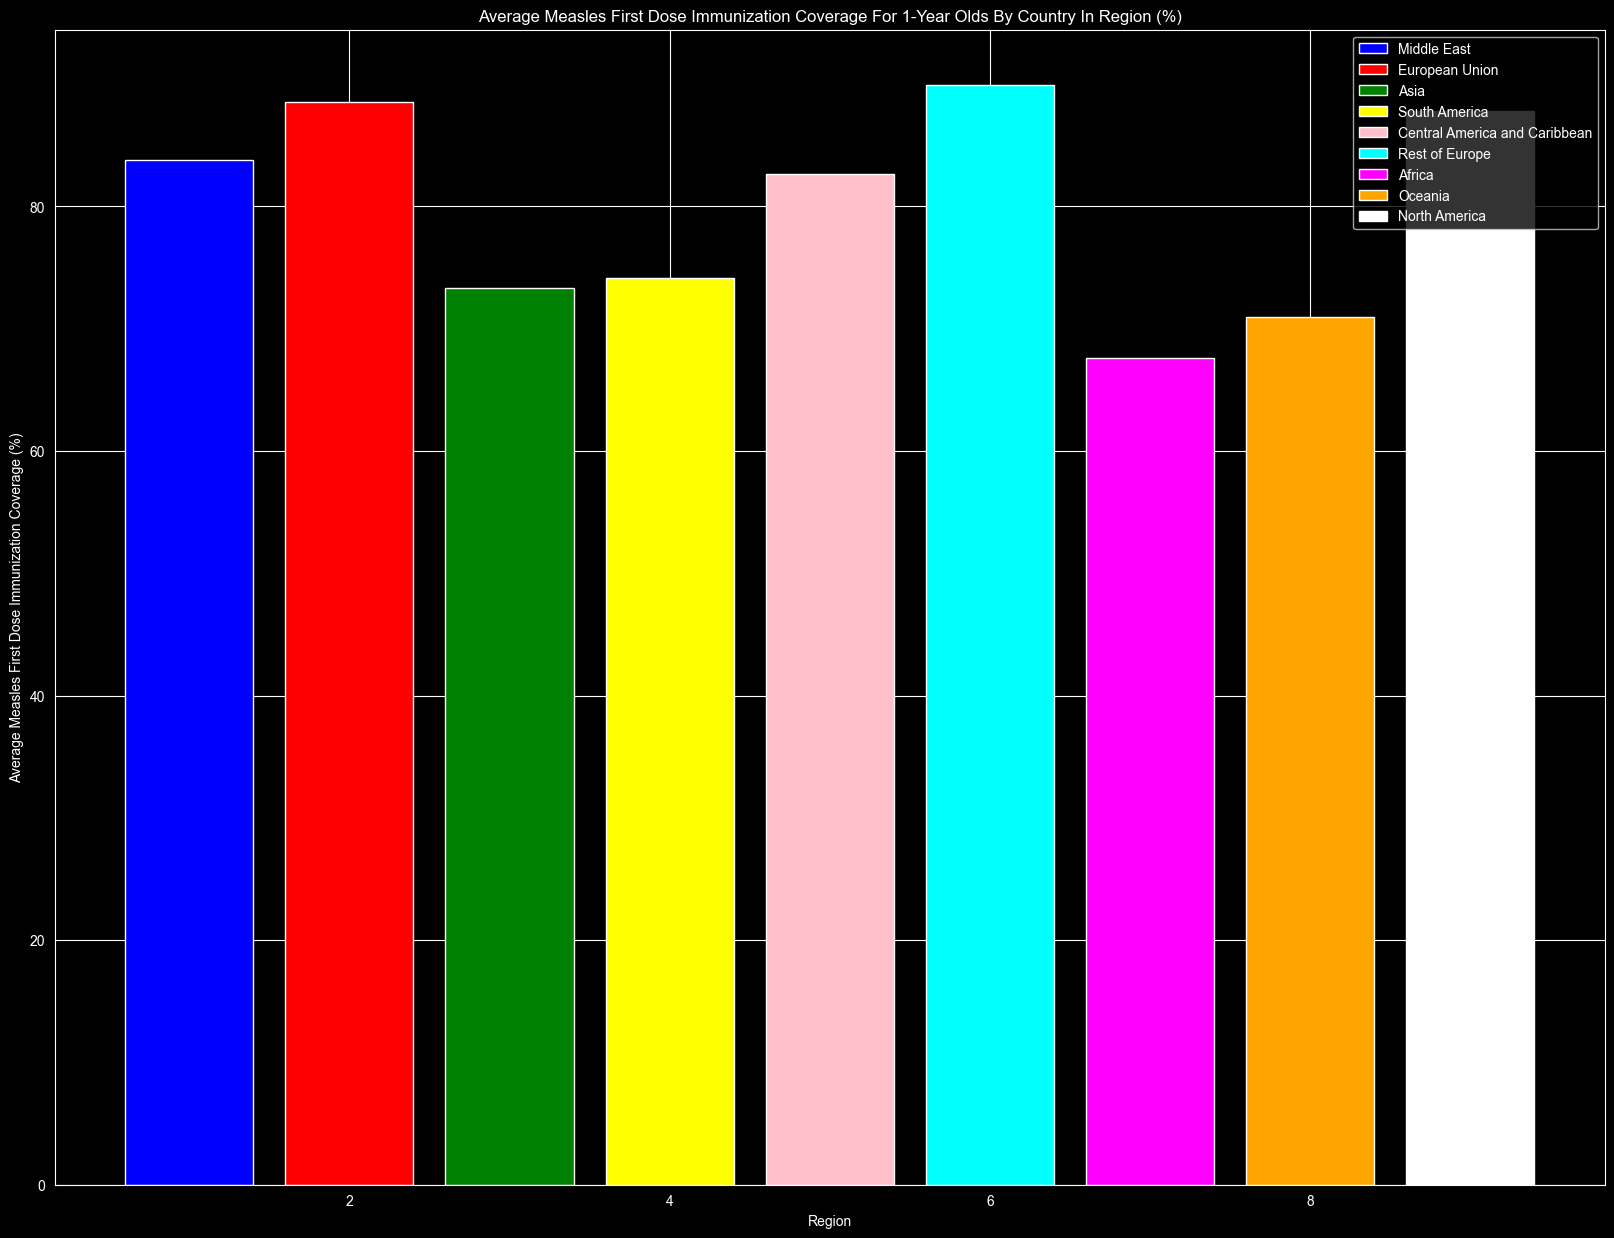

In [17]:
plt.figure(figsize=(20, 15))

# Display distribution by region of average value of (Measles) vaccination and assign color, labels
plt.bar(Measles_Region.index, Measles_Region.values, color=['blue', 'red', 'green', 'yellow', 'pink', 'cyan', 'magenta', 'orange', 'white'], label=['Middle East', 'European Union', 'Asia', 'South America', 'Central America and Caribbean', 'Rest of Europe', 'Africa', 'Oceania', 'North America'])

plt.xlabel("Region")
plt.ylabel("Average Measles First Dose Immunization Coverage (%)")
plt.title("Average Measles First Dose Immunization Coverage For 1-Year Olds By Country In Region (%)")
plt.legend()
plt.show()

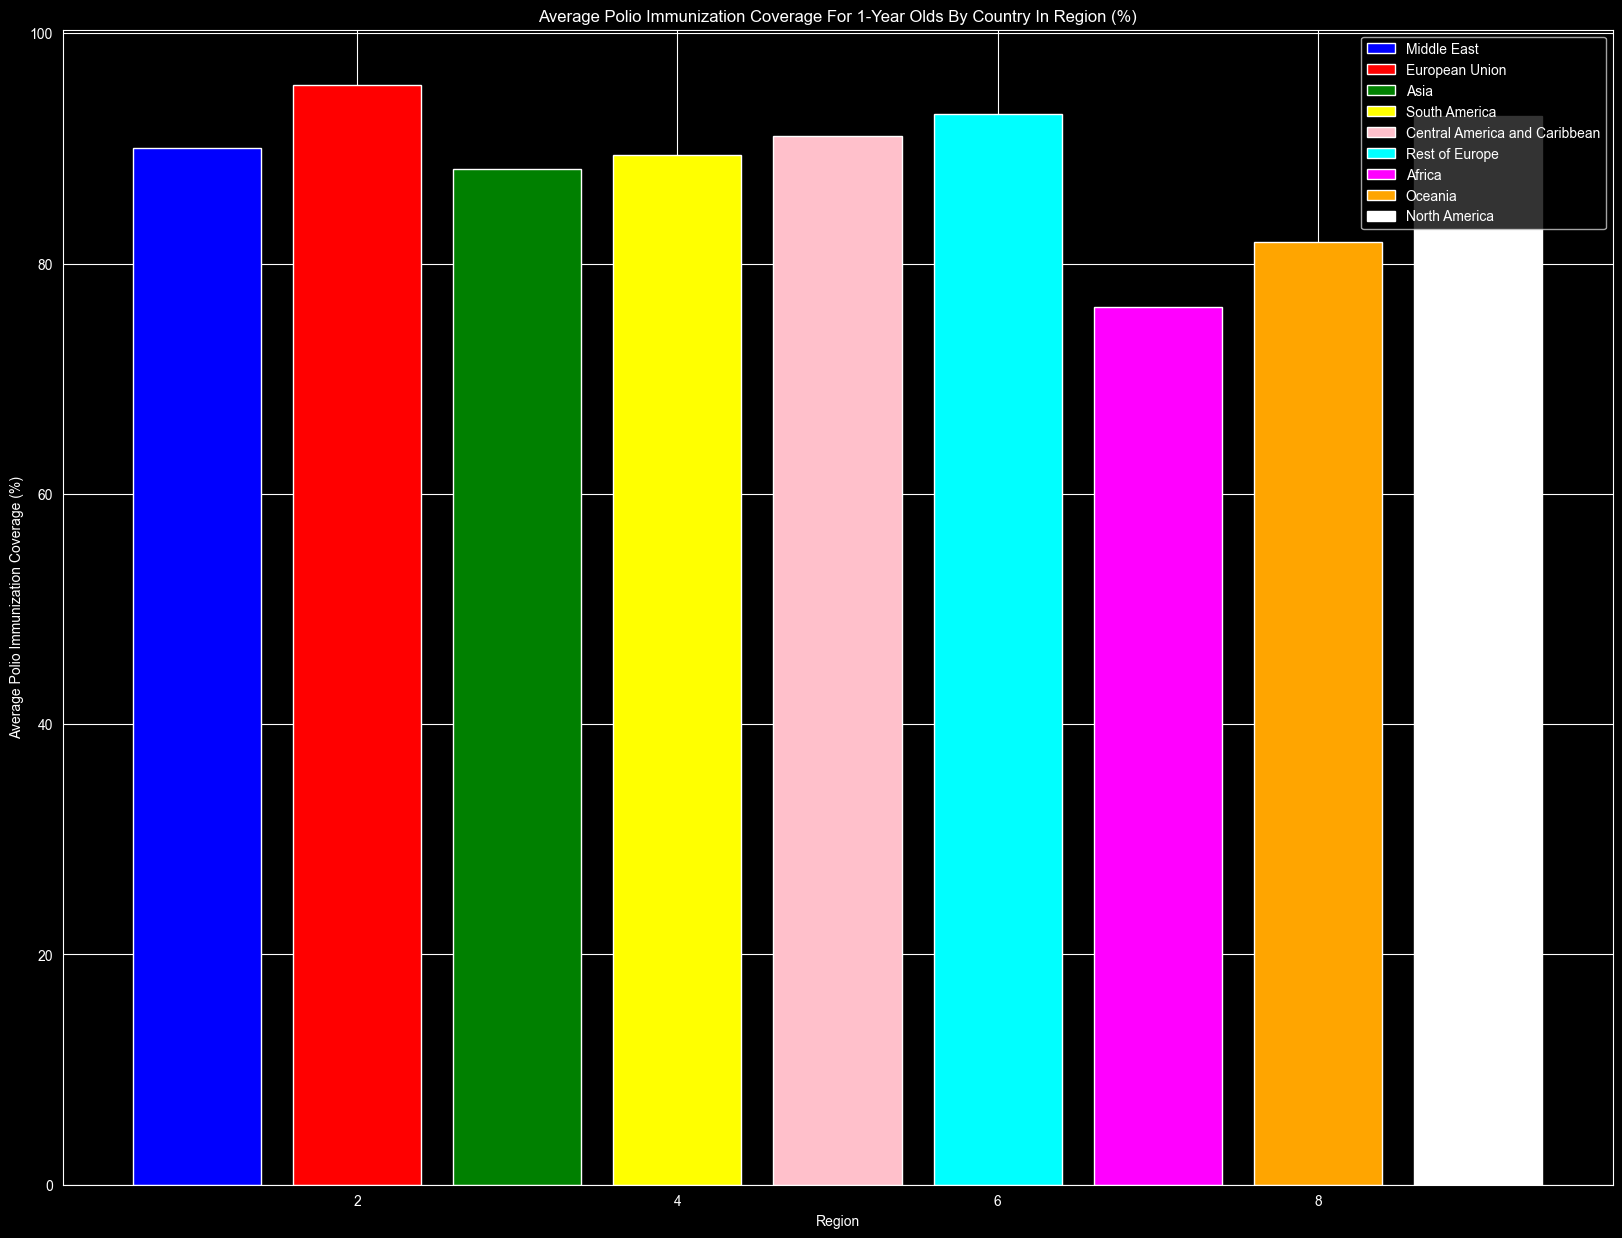

In [18]:
plt.figure(figsize=(20, 15))

# Display distribution by region of average value of (Polio) vaccination and assign color, labels
plt.bar(Polio_Region.index, Polio_Region.values, color=['blue', 'red', 'green', 'yellow', 'pink', 'cyan', 'magenta', 'orange', 'white'], label=['Middle East', 'European Union', 'Asia', 'South America', 'Central America and Caribbean', 'Rest of Europe', 'Africa', 'Oceania', 'North America'])

plt.xlabel("Region")
plt.ylabel("Average Polio Immunization Coverage (%)")
plt.title("Average Polio Immunization Coverage For 1-Year Olds By Country In Region (%)")
plt.legend()
plt.show()

In [ ]:
'MODEL TRAINING AND PREDICTION'
# Split, train and test data to form model that is fit on the training data to create predictions for the average life expectancy of countries in the testing data, forming scatter plot to visualize the relation between the testing data's predicted and actual values

In [19]:
from sklearn import datasets, model_selection
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [20]:
life_df = pd.read_csv(r'C:\Users\mratk\AppData\Local\Life-Expectancy-Data-Updated.csv')

In [21]:
# Encode all categorical variables into numbers
region_map = {'Middle East': 1, 'European Union': 2, 'Asia': 3, 'South America': 4, 'Central America and Caribbean': 5, 'Rest of Europe': 6, 'Africa': 7, 'Oceania': 8, 'North America': 9}
life_df['Region Encoded'] = life_df['Region'].map(region_map) # Create column with numbers

In [22]:
life_df = life_df.drop(['Region'], axis=1) # Drop categorical variable after its encoding

In [23]:
life_df.head()

,Country,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,Polio,...,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status_Developed,Economy_status_Developing,Life_expectancy,Region Encoded
0,Turkiye,2015,11.1,13.0,105.8240,1.32,97,65,27.8,97,...,0.08,11006,78.53,4.9,4.8,7.8,0,1,76.5,1
1,Spain,2015,2.7,3.3,57.9025,10.35,97,94,26.0,97,...,0.09,25742,46.44,0.6,0.5,9.7,1,0,82.8,2
2,India,2007,51.5,67.9,201.0765,1.57,60,35,21.2,67,...,0.13,1076,1183.21,27.1,28.0,5.0,0,1,65.4,3
3,Guyana,2006,32.8,40.5,222.1965,5.68,93,74,25.3,92,...,0.79,4146,0.75,5.7,5.5,7.9,0,1,67.0,4
4,Israel,2012,3.4,4.3,57.9510,2.89,97,89,27.0,94,...,0.08,33995,7.91,1.2,1.1,12.8,1,0,81.7,1


In [24]:
# Assign all numerical features and label encodings as independent variables
x = life_df[['Year', 'Infant_deaths', 'Under_five_deaths', 'Adult_mortality', 'Alcohol_consumption', 'Hepatitis_B', 'Measles', 'BMI', 'Polio', 'Diphtheria', 'Incidents_HIV', 'GDP_per_capita', 'Population_mln', 'Thinness_ten_nineteen_years', 'Thinness_five_nine_years', 'Schooling', 'Economy_status_Developed', 'Economy_status_Developing', 'Region Encoded']]
y = life_df['Life_expectancy'] # Assign the target variable

In [25]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(x, y, test_size=0.2, random_state=42) # Train model on independent variables to test it on 20% of data

In [26]:
from sklearn.linear_model import LinearRegression

In [27]:
model_1 = LinearRegression()

In [28]:
model_1.fit(X_train, y_train) # Fit model to training data to test it

prediction = model_1.predict(X_test) # Form model's predictions from test data

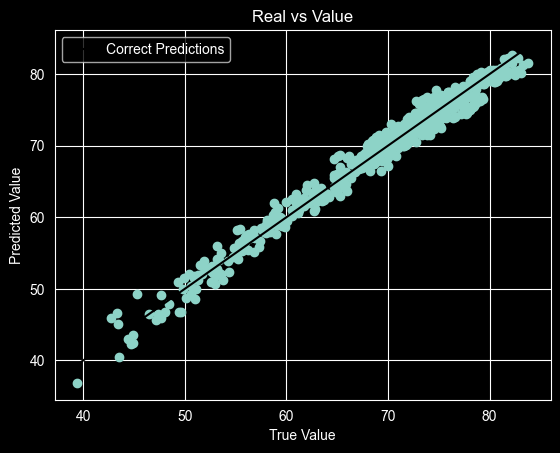

In [29]:
plt.scatter(y_test, prediction) # Create scatter plot comparing value of target variable to predictions
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color = 'black', label='Correct Predictions')

plt.xlabel('True Value')
plt.ylabel('Predicted Value')
plt.title('Real vs Value')
plt.legend()

plt.show()

In [ ]:
'MODEL PREDICTIONS'
# Use model to predict life expectancy of a country for a year from the value of its features, plot the expected relation between two independent features used in the testing data to show if they are correlated positively or negatively

In [30]:
country_1 = pd.DataFrame([[2012, 32, 41, 417, 1.2, 74, 68, 21, 76, 71, 12.2, 56824, 112, 7, 11, 9, 0, 1, 7]], columns=["Year", "Infant_deaths", "Under_five_deaths", "Adult_mortality", "Alcohol_consumption", "Hepatitis_B", "Measles", "BMI", "Polio", "Diphtheria", "Incidents_HIV", "GDP_per_capita", "Population_mln", "Thinness_ten_nineteen_years", "Thinness_five_nine_years", "Schooling", "Economy_status_Developed", "Economy_status_Developing", "Region Encoded"])
country1_prediction = model_1.predict(country_1.values)[0]
print(f'Predicted Life Expectancy (Country 1): {country1_prediction}')

Predicted Life Expectancy (Country 1): 60.45545414994827


In [31]:
country_2 = pd.DataFrame([[2012, 121, 63, 269, 2.7, 87, 81, 27, 88, 88, 2.6, 73451, 341, 4, 7, 13, 1, 0, 9]], columns=["Year", "Infant_deaths", "Under_five_deaths", "Adult_mortality", "Alcohol_consumption", "Hepatitis_B", "Measles", "BMI", "Polio", "Diphtheria", "Incidents_HIV", "GDP_per_capita", "Population_mln", "Thinness_ten_nineteen_years", "Thinness_five_nine_years", "Schooling", "Economy_status_Developed", "Economy_status_Developing", "Region Encoded"])
country2_prediction = model_1.predict(country_2.values)[0]
print(f'Predicted Life Expectancy (Country 2): {country2_prediction}')

Predicted Life Expectancy (Country 2): 61.33095696265056


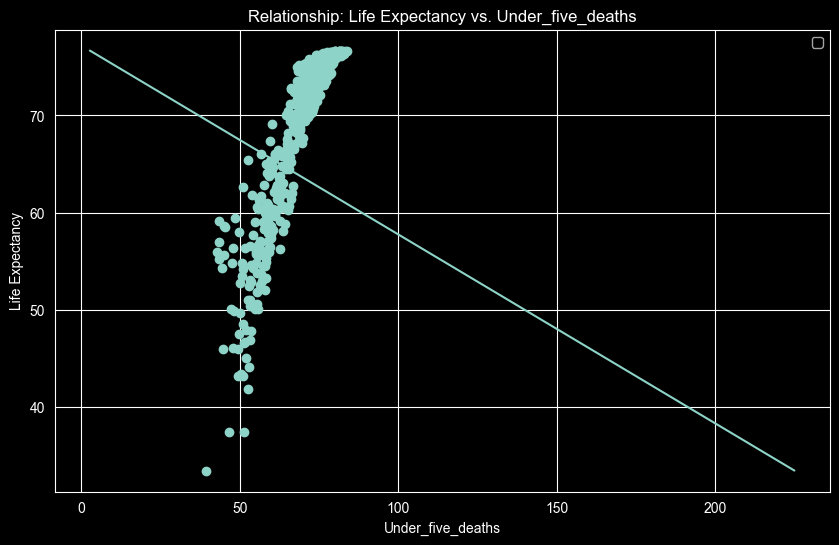

In [32]:
x = life_df[['Under_five_deaths']]
y = life_df[['Life_expectancy']]

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model_relationship = LinearRegression()
model_relationship.fit(X_train, y_train)

relationship_prediction = model_relationship.predict(X_test)

plt.figure(figsize=(10,6))

plt.scatter(y_test, relationship_prediction)

sorted = np.argsort(X_test.values.flatten())
plt.plot(X_test.values[sorted], relationship_prediction[sorted])

plt.title('Relationship: Life Expectancy vs. Under_five_deaths')
plt.xlabel('Under_five_deaths')
plt.ylabel('Life Expectancy')
plt.legend()
plt.show()

In [ ]:
'DUMMY VARIABLE MODEL TRAINING AND PREDICTION'
# Split, train and test data to form model through creation of dummy variables using one-hot encoding to create predictions for the average life expectancy of countries in the testing data, forming scatter plot to visualize the relation between the testing data's predicted and actual values

In [33]:
life_df = pd.read_csv(r'C:\Users\mratk\AppData\Local\Life-Expectancy-Data-Updated.csv')

# Encode all categorical variables into numbers
region_map = {'Middle East': 1, 'European Union': 2, 'Asia': 3, 'South America': 4, 'Central America and Caribbean': 5, 'Rest of Europe': 6, 'Africa': 7, 'Oceania': 8, 'North America': 9}
life_df['Region Encoded'] = life_df['Region'].map(region_map) # Create column with numbers
life_df = life_df.drop(['Region'], axis=1) # Drop categorical variable after its encoding
life_df = life_df.drop(['Country'], axis=1)

In [34]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

life_df['Region Encoded'] = life_df['Region Encoded'].astype('category')

df_encoded = pd.get_dummies(life_df, columns=['Region Encoded'], prefix='Region', dtype=int)

df_encoded.head()

,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,Polio,Diphtheria,...,Life_expectancy,Region_1,Region_2,Region_3,Region_4,Region_5,Region_6,Region_7,Region_8,Region_9
0,2015,11.1,13.0,105.8240,1.32,97,65,27.8,97,97,...,76.5,1,0,0,0,0,0,0,0,0
1,2015,2.7,3.3,57.9025,10.35,97,94,26.0,97,97,...,82.8,0,1,0,0,0,0,0,0,0
2,2007,51.5,67.9,201.0765,1.57,60,35,21.2,67,64,...,65.4,0,0,1,0,0,0,0,0,0
3,2006,32.8,40.5,222.1965,5.68,93,74,25.3,92,93,...,67.0,0,0,0,1,0,0,0,0,0
4,2012,3.4,4.3,57.9510,2.89,97,89,27.0,94,94,...,81.7,1,0,0,0,0,0,0,0,0


In [35]:
x = df_encoded.drop(columns=['Life_expectancy'])
y = df_encoded['Life_expectancy']

In [36]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model = LinearRegression()

In [37]:
model.fit(X_train, y_train)

prediction_dummy = model.predict(X_test)

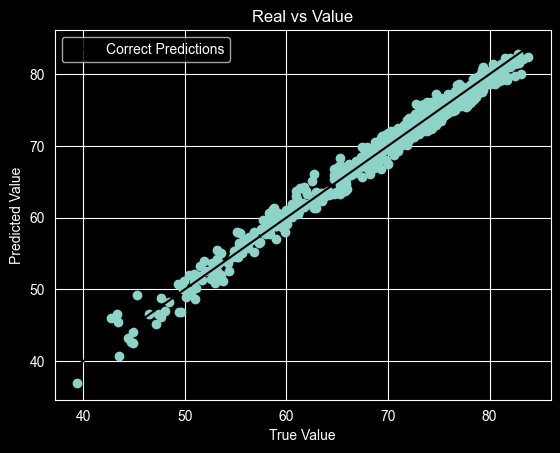

In [38]:
# Create scatter plot comparing value of target variable to predictions
plt.scatter(y_test, prediction_dummy)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='black', label='Correct Predictions')

plt.xlabel('True Value')
plt.ylabel('Predicted Value')
plt.title('Real vs Value')
plt.legend()

plt.show()

In [ ]:
'DUMMY VARIABLE MODEL PREDICTIONS'
# Use dummy variable model to predict life expectancy of a country for a year from the value of its features, plot the expected relation between two independent features used in the testing data to show if they are correlated positively or negatively

In [39]:
country1_dummy = pd.DataFrame([[2012, 32, 41, 417, 1.2, 74, 68, 21, 76, 71, 12.2, 56824, 112, 7, 11, 9, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0]], columns=["Year", "Infant_deaths", "Under_five_deaths", "Adult_mortality", "Alcohol_consumption", "Hepatitis_B", "Measles", "BMI", "Polio", "Diphtheria", "Incidents_HIV", "GDP_per_capita", "Population_mln", "Thinness_ten_nineteen_years", "Thinness_five_nine_years", "Schooling", "Economy_status_Developed", "Economy_status_Developing", "Region_1", "Region_2", "Region_3", "Region_4", "Region_5", "Region_6", "Region_7", "Region_8", "Region_9"])
country1dummy_prediction = model.predict(country1_dummy.values)[0]
print(f'Predicted Life Expectancy (Country 1): {country1dummy_prediction}')

Predicted Life Expectancy (Country 1): 60.41375229931606


In [40]:
country2_dummy = pd.DataFrame([[2012, 121, 63, 269, 2.7, 87, 81, 27, 88, 88, 2.6, 73451, 341, 4, 7, 13, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]], columns=["Year", "Infant_deaths", "Under_five_deaths", "Adult_mortality", "Alcohol_consumption", "Hepatitis_B", "Measles", "BMI", "Polio", "Diphtheria", "Incidents_HIV", "GDP_per_capita", "Population_mln", "Thinness_ten_nineteen_years", "Thinness_five_nine_years", "Schooling", "Economy_status_Developed", "Economy_status_Developing", "Region_1", "Region_2", "Region_3", "Region_4", "Region_5", "Region_6", "Region_7", "Region_8", "Region_9"])
country2dummy_prediction = model.predict(country2_dummy.values)[0]
print(f'Predicted Life Expectancy (Country 2): {country2dummy_prediction}')

Predicted Life Expectancy (Country 2): 63.501118717204555


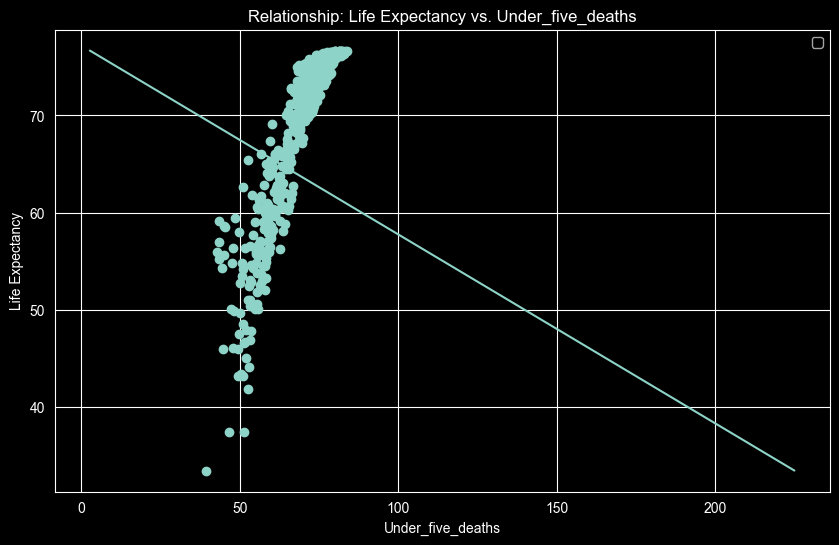

In [41]:
x = df_encoded[['Under_five_deaths']]
y = df_encoded[['Life_expectancy']]

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model_relationship2 = LinearRegression()
model_relationship2.fit(X_train, y_train)

relationship2_prediction = model_relationship2.predict(X_test)

plt.figure(figsize=(10,6))

plt.scatter(y_test, relationship2_prediction)

sorted = np.argsort(X_test.values.flatten())
plt.plot(X_test.values[sorted], relationship2_prediction[sorted])

plt.title('Relationship: Life Expectancy vs. Under_five_deaths')
plt.xlabel('Under_five_deaths')
plt.ylabel('Life Expectancy')
plt.legend()
plt.show()

In [ ]:
'BEST FEATURES MODEL TRAINING AND PREDICTIONS'
# Use model involving 10 most correlated features to the dependent variable to predict life expectancy of a country for a year in order to maximize evaluated accuracy

In [42]:
# Set life expectancy as dependent variable and compute its correlation to all independent variables
target = "Life_expectancy"
correlation = life_df.corr()

In [43]:
# Compute correlation of each independent variable with the dependent variable, sort by highest values
correlations = correlation[target].drop(target)
correlations = correlations.abs().sort_values(ascending=False)

In [44]:
# Select 10 most correlated features to the dependent variable from independent variables
features = correlations.head(10).reset_index()
print(features)

                       index  Life_expectancy
0            Adult_mortality         0.945360
1          Under_five_deaths         0.920419
2              Infant_deaths         0.920032
3                  Schooling         0.732484
4                      Polio         0.641217
5                 Diphtheria         0.627541
6                        BMI         0.598423
7             GDP_per_capita         0.583090
8              Incidents_HIV         0.553027
9  Economy_status_Developing         0.523791


In [45]:
x = life_df[["Adult_mortality", "Under_five_deaths", "Infant_deaths", "Schooling", "Diphtheria", "GDP_per_capita", "Incidents_HIV", "Polio", "BMI", "Economy_status_Developing"]]
y = life_df[["Life_expectancy"]]

In [46]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(x, y, test_size=0.2, random_state=42)

In [47]:
from sklearn.linear_model import LinearRegression

In [48]:
model_4best = LinearRegression()

model_4best.fit(X_train, y_train) # Fit model to training data to test it

prediction_4best = model_4best.predict(X_test)

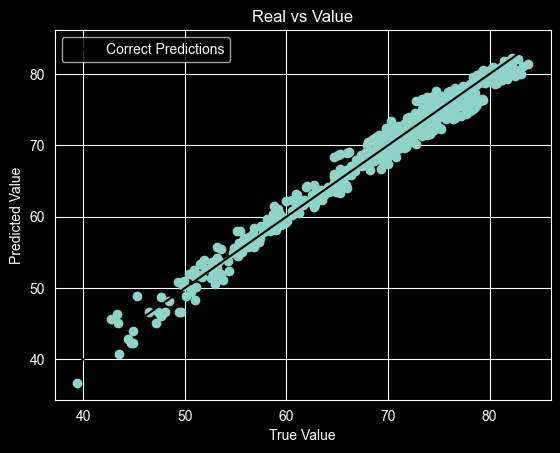

In [49]:
plt.scatter(y_test, prediction_4best)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='black', label='Correct Predictions')

plt.xlabel('True Value')
plt.ylabel('Predicted Value')
plt.title('Real vs Value')
plt.legend()

plt.show()

In [50]:
# Group target variable of life expectancy into bins of 5 years to test prediction model's accuracy
y_test1 = np.squeeze(y_test)
prediction_4best1 = np.squeeze(prediction_4best)

bin = [50, 55, 60, 65, 70, 75, 80, 85]

true_bin = pd.cut(y_test1, bins=bin, labels=False, include_lowest=True)
prediction_bin = pd.cut(prediction_4best1, bins=bin, labels=False, include_lowest=True)

In [51]:
values = ~np.isnan(true_bin) & ~np.isnan(prediction_bin)
true_bin1 = true_bin[values].astype(int)
prediction_bin1 = prediction_bin[values].astype(int)

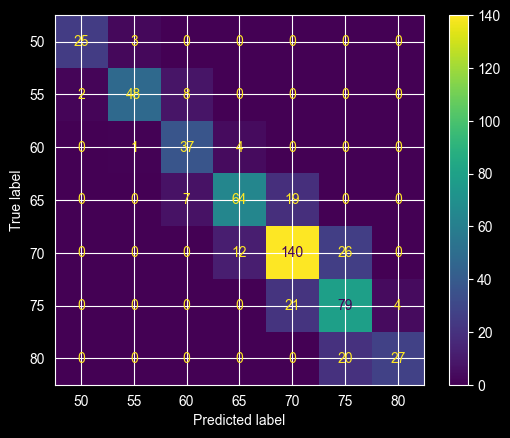

In [52]:
cm = confusion_matrix(true_bin1, prediction_bin1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=bin[:-1])
disp.plot()
plt.show()

In [53]:
accuracy = accuracy_score(true_bin1, prediction_bin1) # Calculate accuracy of predictions
print(f'Accuracy: {accuracy * 100}%') # Return accuracy of predictions in a percentage format

Accuracy: 76.78244972577697%


In [54]:
# Group target variable of life expectancy into bins of 7 years to test prediction model's accuracy
y_test2 = np.squeeze(y_test)
prediction_4best2 = np.squeeze(prediction_4best)

bin = [52, 59, 66, 73, 80, 87]

true_bin2 = pd.cut(y_test2, bins=bin, labels=False, include_lowest=True)
prediction_bin2 = pd.cut(prediction_4best2, bins=bin, labels=False, include_lowest=True)

In [55]:
values = ~np.isnan(true_bin2) & ~np.isnan(prediction_bin2)
true_bin2 = true_bin2[values].astype(int)
prediction_bin2 = prediction_bin2[values].astype(int)

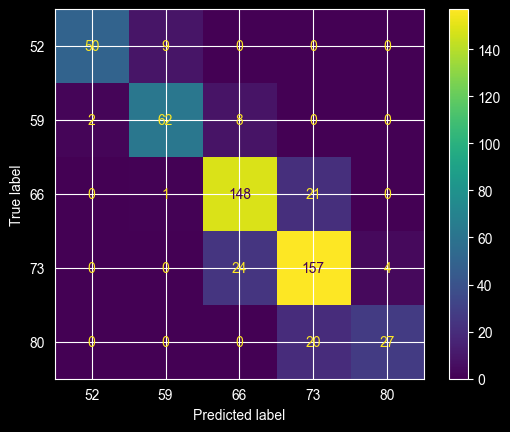

In [56]:
cm = confusion_matrix(true_bin2, prediction_bin2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=bin[:-1])
disp.plot()
plt.show()

In [57]:
accuracy = accuracy_score(true_bin2, prediction_bin2)  # Calculate accuracy of predictions
print(f'Accuracy: {accuracy * 100}%')  # Return accuracy of predictions in a percentage format

Accuracy: 83.30206378986867%


In [58]:
# Group target variable of life expectancy into bins of 10 years to test prediction model's accuracy
y_test3 = np.squeeze(y_test)
prediction_4best3 = np.squeeze(prediction_4best)

bin = [54, 64, 74, 84]

true_bin3 = pd.cut(y_test3, bins=bin, labels=False, include_lowest=True)
prediction_bin3 = pd.cut(prediction_4best3, bins=bin, labels=False, include_lowest=True)

In [59]:
values = ~np.isnan(true_bin3) & ~np.isnan(prediction_bin3)
true_bin3 = true_bin3[values].astype(int)
prediction_bin3 = prediction_bin3[values].astype(int)

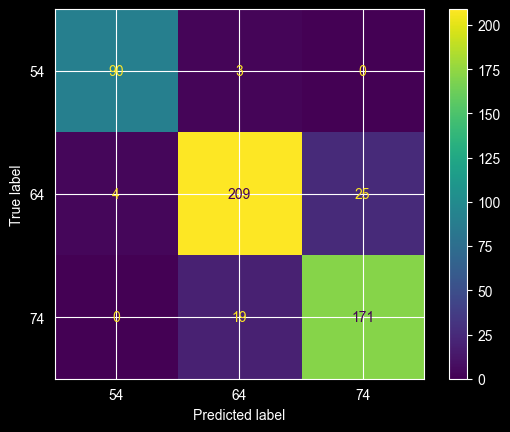

In [60]:
cm = confusion_matrix(true_bin3, prediction_bin3)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=bin[:-1])
disp.plot()
plt.show()

In [61]:
accuracy = accuracy_score(true_bin3, prediction_bin3)  # Calculate accuracy of predictions
print(f'Accuracy: {accuracy * 100}%')  # Return accuracy of predictions in a percentage format

Accuracy: 90.21113243761995%
